In [8]:
# Channel W1 (Comparison of number of Traces (N) vs the sequence length (n))
# Author: Jaswanthi Mandalapu
# Date: 07 Apr 2026

import numpy as np
import matplotlib.pyplot as plt

n = 10
# X ~ i.i.d. Bernoulli(1/2)
X = np.random.randint(0, 2, size=n)

print("X =", X)

X = [1 1 0 1 0 0 0 1 0 0]


In [10]:
def channel_W1(x):
  n = len(x)

  # pick R ~ Uniform[0, n]
  R = np.random.randint(0, n + 1)

  y = x.copy()

  # replace last R bits
  if R > 0:
      y[n - R:] = np.random.randint(0, 2, size=R)

  return y

In [11]:
def channel_W2(x):
  n = len(x)

  # pick R ~ Uniform[0, n]
  R = np.random.randint(0, (n + 1)//2)
  L = np.random.randint(0, (n + 1)//2)


  y = x.copy()

  # replace last R bits
  if R > 0:
      y[n - R:] = np.random.randint(0, 2, size=R)

  # replace first L bits
  if L > 0:
      y[:L] = np.random.randint(0, 2, size=L)

  return y

In [16]:
def channel_W3(x):
  n = len(x)

  # pick R ~ Uniform[0, n]
  R = np.random.randint(0, n + 1)
  T= np.random.randint(0,n+1)
#   print("R =", R, "T =", T)
  y = x.copy()
  y=y[:n-R]
  # replace last R bits
  if T > 0:
      z=np.random.randint(0, 2, size=T)
      y=np.concatenate((y,z))
  

  return y

In [17]:
print(channel_W1(X))
print(channel_W2(X))
print(channel_W3(X))



[1 1 0 1 0 1 1 0 1 1]
[1 0 1 0 0 0 1 1 1 1]
[1 1 0 1 0 0 0 1 1 0 1 1 0 0 0]


In [18]:
def generate_traces(x, N, channel_func=channel_W1):
  traces = []

  for _ in range(N):
      y = channel_func(x)
      traces.append(y)

  return np.array(traces, dtype=object)

In [19]:
def estimate_x_bitwise(traces):
  N = traces.shape[0]

  # Handle variable-length traces by finding average length
  avg_length = sum(len(trace) for trace in traces)//len(traces)
  
  # sum across traces (only for positions that exist in all traces)
  ones = np.zeros(avg_length)
  for i in range(avg_length):
      for trace in traces:
          # Skip if trace is too short for this index
          if i < len(trace):
              ones[i] += trace[i]

  # majority vote
  x_hat = (ones > N/2).astype(int)

  return x_hat


In [20]:
def estimate_x_pfm(traces):

  N = traces.shape[0]
  
  avg_length = sum(len(trace) for trace in traces)//len(traces)
  
  # Start with all traces
  subset = list(range(N))
  x_hat = []
  
  # Go through each bit position from left to right
  for i in range(avg_length):
    if len(subset) == 0:
      majority_bit = 0  # Default to 0 if no traces left
    else:
      # Only count traces that have index i
      valid_subset = [j for j in subset if i < len(traces[j])]
      
      if len(valid_subset) == 0:
        majority_bit = 0  # Default to 0 if all traces are too short
      else:
        ones = sum(traces[j][i] for j in valid_subset)  
        # Determine majority bit
        majority_bit = 1 if ones > len(valid_subset) / 2 else 0
        subset = [j for j in valid_subset if traces[j][i] == majority_bit]
      
    x_hat.append(majority_bit)  
      
  return np.array(x_hat)


In [24]:
def estimate_error_prob(n, N, channel_func,estimate_func=estimate_x_bitwise, trials=1000):
  errors = 0

  for _ in range(trials):
      X = np.random.randint(0, 2, size=n)
      traces = generate_traces(X, N, channel_func)
      X_hat = estimate_func(traces)

      if not np.array_equal(X, X_hat):
          errors += 1

  return errors / trials

In [25]:
n = 20

for N in range(50, 5000, 50):
    err = estimate_error_prob(n, N, channel_W1, estimate_x_bitwise, trials=500)

    print("N =", N, "Error =", err)

    if err < 0.01:
        print("Found N =", N)
        break

N = 50 Error = 0.65
N = 100 Error = 0.48
N = 150 Error = 0.406
N = 200 Error = 0.304


KeyboardInterrupt: 

In [26]:
n = 25

for N in range(50, 5000, 50):
    err = estimate_error_prob(n, N, channel_W3, estimate_x_bitwise,trials=500)

    print("N =", N, "Error =", err)

    if err < 0.01:
        print("Found N =", N)
        break

N = 50 Error = 0.998
N = 100 Error = 0.992
N = 150 Error = 0.994
N = 200 Error = 0.994
N = 250 Error = 0.992
N = 300 Error = 0.996
N = 350 Error = 0.992
N = 400 Error = 0.992
N = 450 Error = 0.986
N = 500 Error = 0.998
N = 550 Error = 0.996
N = 600 Error = 0.994
N = 650 Error = 0.996
N = 700 Error = 0.994
N = 750 Error = 0.99
N = 800 Error = 0.99
N = 850 Error = 0.998
N = 900 Error = 0.99


KeyboardInterrupt: 

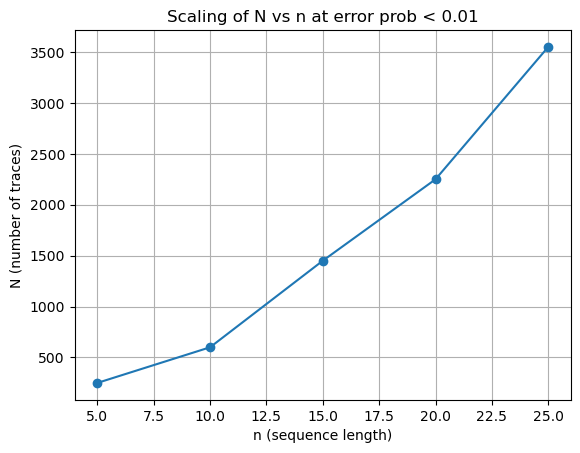

In [27]:
import matplotlib.pyplot as plt

n = [5, 10, 15, 20, 25]
N = [250, 600, 1450, 2250, 3550]

plt.plot(n, N, marker='o')

plt.xlabel("n (sequence length)")
plt.ylabel("N (number of traces)")
plt.title("Scaling of N vs n at error prob < 0.01")

plt.grid(True)
plt.show()

In [28]:
import csv

channels = {
    'W1': channel_W1,
    'W2': channel_W2
    # 'W3': channel_W3
}

n_values = [5, 10, 15, 20, 25]
results = []

for channel_name, channel_func in channels.items():
    for n in n_values:
        for N in range(50, 5000, 50):
            err = estimate_error_prob(n, N, channel_func,estimate_x_bitwise, trials=500)
            
            if err < 0.01:
                results.append({
                    'Channel': channel_name,
                    'n': n,
                    'N': N,
                    'Error': err
                })
                print(f"Channel {channel_name}, n={n}: Found N={N}, Error={err:.4f}")
                break

# Save to CSV
with open('channel_results.csv', 'w', newline='') as csvfile:
    fieldnames = ['Channel', 'n', 'N', 'Error']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    
    writer.writeheader()
    writer.writerows(results)

print("\nResults saved to channel_results.csv")
print(results)

Channel W1, n=5: Found N=250, Error=0.0060
Channel W1, n=10: Found N=600, Error=0.0060
Channel W1, n=15: Found N=1300, Error=0.0060
Channel W1, n=20: Found N=2200, Error=0.0020
Channel W1, n=25: Found N=3100, Error=0.0080
Channel W2, n=5: Found N=50, Error=0.0040
Channel W2, n=10: Found N=200, Error=0.0060
Channel W2, n=15: Found N=450, Error=0.0040
Channel W2, n=20: Found N=650, Error=0.0080
Channel W2, n=25: Found N=1050, Error=0.0060

Results saved to channel_results.csv
[{'Channel': 'W1', 'n': 5, 'N': 250, 'Error': 0.006}, {'Channel': 'W1', 'n': 10, 'N': 600, 'Error': 0.006}, {'Channel': 'W1', 'n': 15, 'N': 1300, 'Error': 0.006}, {'Channel': 'W1', 'n': 20, 'N': 2200, 'Error': 0.002}, {'Channel': 'W1', 'n': 25, 'N': 3100, 'Error': 0.008}, {'Channel': 'W2', 'n': 5, 'N': 50, 'Error': 0.004}, {'Channel': 'W2', 'n': 10, 'N': 200, 'Error': 0.006}, {'Channel': 'W2', 'n': 15, 'N': 450, 'Error': 0.004}, {'Channel': 'W2', 'n': 20, 'N': 650, 'Error': 0.008}, {'Channel': 'W2', 'n': 25, 'N': 10

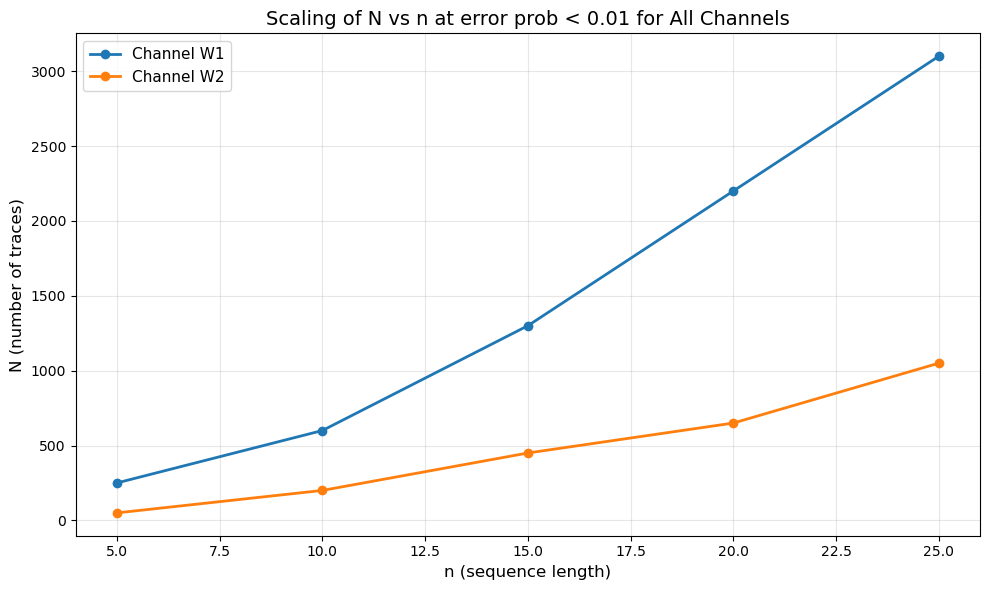

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Read CSV file
df = pd.read_csv('channel_results.csv')

# Create plot
plt.figure(figsize=(10, 6))

# Plot each channel
for channel in df['Channel'].unique():
    channel_data = df[df['Channel'] == channel].sort_values('n')
    plt.plot(channel_data['n'], channel_data['N'], marker='o', label=f'Channel {channel}', linewidth=2)

plt.xlabel('n (sequence length)', fontsize=12)
plt.ylabel('N (number of traces)', fontsize=12)
plt.title('Scaling of N vs n at error prob < 0.01 for All Channels', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()